In [100]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import krippendorff
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
import numpy as np


In [89]:
distory = pd.read_csv("./data/DisasterStory.csv")

In [90]:

new_data = []

# Iterate over each disaster type
for disaster_type, group in distory.groupby('Disaster Type'):
    for _, row in group.iterrows():
        # Extract triplets
        triplets = eval(row['llama graph'])  # Assuming 'llama graph' is a string representation of a list
        
        # Concatenate storyline text, converting each element to a string and handling missing values
        storyline = ' '.join([
            str(row['key information'] or ''),
            str(row['severity'] or ''),
            str(row['key drivers'] or ''),
            str(row['main impacts, exposure, and vulnerability'] or ''),
            str(row['likelihood of multi-hazard risks'] or ''),
            str(row['best practices for managing this risk'] or ''),
            str(row['recommendations and supportive measures for recovery'] or '')
        ])
        
        # Add entries to the new data list
        for triplet in triplets:
            new_data.append((triplet, disaster_type, storyline))

# Randomly sample 1000 triplets if there are more than 1000
if len(new_data) > 1000:
    new_data = random.sample(new_data, 1000)

# Create a new DataFrame
new_df = pd.DataFrame(new_data, columns=['Triplet', 'Disaster Type', 'Storyline'])

In [91]:
new_df["Disaster Type"].value_counts()

Disaster Type
Flood                               314
Storm                               292
Earthquake                           73
Road                                 70
Wildfire                             45
Mass movement (wet)                  36
Epidemic                             25
Fire (Miscellaneous)                 23
Collapse (Industrial)                16
Drought                              14
Water                                13
Explosion (Industrial)               13
Extreme temperature                  11
Miscellaneous accident (General)     10
Rail                                 10
Collapse (Miscellaneous)              8
Volcanic activity                     7
Air                                   6
Fire (Industrial)                     5
Explosion (Miscellaneous)             4
Industrial accident (General)         3
Glacial lake outburst flood           1
Gas leak                              1
Name: count, dtype: int64

In [95]:
new_df = pd.read_excel("./data/triplet_expert_val.xlsx")

In [96]:
new_df.head()

,Triplet,Disaster Type,Storyline,Expert_1,Expert_2,Expert_3,Expert_4,Expert_5,Expert_6
0,"('nipah virus', 'causes', 'epidemic')",Epidemic,An epidemic event related to the Nipah virus o...,1,1,1,1,1,1
1,"('flooding', 'causes', 'fatalities')",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",0,0,1,0,0,0
2,"('heavy rain', 'causes', 'flooding')",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,0,1,1,1,0,0
3,"('early intervention', 'prevents', 'casualties')",Flood,"A flood disaster occurred in South Africa, spe...",0,0,0,0,0,0
4,"('landslide', 'causes', 'economic damage')",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,0,1,1,1,0,1


In [97]:
# List of expert columns
experts = [f'Expert_{i}' for i in range(1, 7)]

# Ground truth: the LLM always predicts 1
new_df['LLM'] = 1

# -----------------------------
# Precision function
# -----------------------------
def precision(y_pred, y_true):
    """
    Precision = # correctly predicted 1's / # predicted 1's
    """
    return sum((y_pred == 1) & (y_true == 1)) / max(sum(y_pred == 1), 1)  # avoid div by 0

# -----------------------------
# 1️⃣ Majority vote
# -----------------------------
new_df['Majority'] = (new_df[experts].sum(axis=1) >= 4).astype(int)

# -----------------------------
# 2️⃣ Precision per expert and majority
# -----------------------------
precision_dict = {}
for exp in experts:
    precision_dict[exp] = precision(new_df['LLM'], new_df[exp])

precision_dict['Majority'] = precision(new_df['LLM'], new_df['Majority'])

precision_df = pd.DataFrame.from_dict(precision_dict, orient='index', columns=['Precision'])
print("Precision per expert and majority vote:")
print(precision_df)

# -----------------------------
# 3️⃣ Krippendorff's alpha (inter-annotator agreement)
# -----------------------------
data_matrix = new_df[experts].T.values  # shape: raters x items
alpha = krippendorff.alpha(reliability_data=data_matrix, level_of_measurement='nominal')
print(f"Krippendorff's alpha (all experts): {alpha:.3f}")


Precision per expert and majority vote:
          Precision
Expert_1      0.510
Expert_2      0.853
Expert_3      0.836
Expert_4      0.648
Expert_5      0.426
Expert_6      0.750
Majority      0.640
Krippendorff's alpha (all experts): 0.425


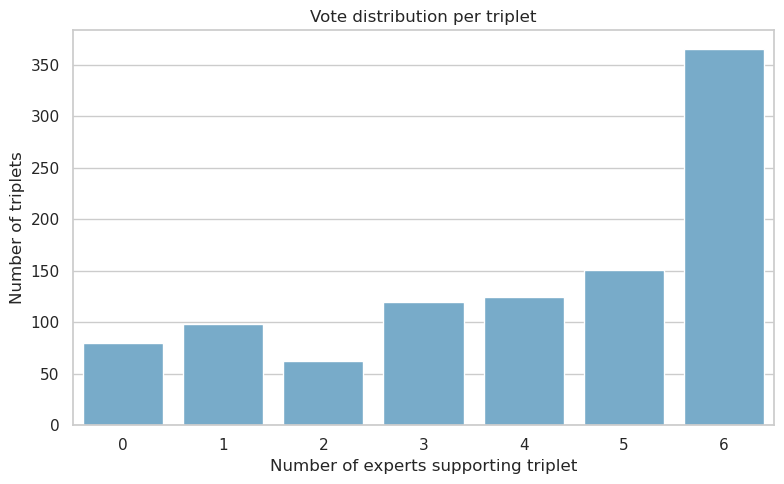

In [99]:
# 4️⃣ Vote distribution per triplet
# -----------------------------
new_df['Votes'] = new_df[experts].sum(axis=1)

vote_counts = new_df['Votes'].value_counts().sort_index()

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x=vote_counts.index, y=vote_counts.values, color="#6BAED6")
plt.xlabel("Number of experts supporting triplet")
plt.ylabel("Number of triplets")
plt.title("Vote distribution per triplet")
plt.tight_layout()
plt.show()

In [101]:

# List of experts
experts = [f'Expert_{i}' for i in range(1, 7)]

# Compute pairwise Cohen's kappa
pairwise_kappa = {}
for exp1, exp2 in combinations(experts, 2):
    kappa = cohen_kappa_score(new_df[exp1], new_df[exp2])
    pairwise_kappa[f'{exp1} vs {exp2}'] = kappa

pairwise_kappa_df = pd.DataFrame.from_dict(pairwise_kappa, orient='index', columns=['Cohen_kappa'])

# Compute average kappa
average_kappa = np.mean(list(pairwise_kappa.values()))

print("Pairwise Cohen's kappa between experts:")
print(pairwise_kappa_df)
print(f"\nAverage pairwise Cohen's kappa: {average_kappa:.3f}")

Pairwise Cohen's kappa between experts:
                      Cohen_kappa
Expert_1 vs Expert_2     0.292003
Expert_1 vs Expert_3     0.306682
Expert_1 vs Expert_4     0.597618
Expert_1 vs Expert_5     0.664992
Expert_1 vs Expert_6     0.515152
Expert_2 vs Expert_3     0.493881
Expert_2 vs Expert_4     0.456401
Expert_2 vs Expert_5     0.219548
Expert_2 vs Expert_6     0.595054
Expert_3 vs Expert_4     0.445754
Expert_3 vs Expert_5     0.206880
Expert_3 vs Expert_6     0.554217
Expert_4 vs Expert_5     0.471167
Expert_4 vs Expert_6     0.577465
Expert_5 vs Expert_6     0.363128

Average pairwise Cohen's kappa: 0.451


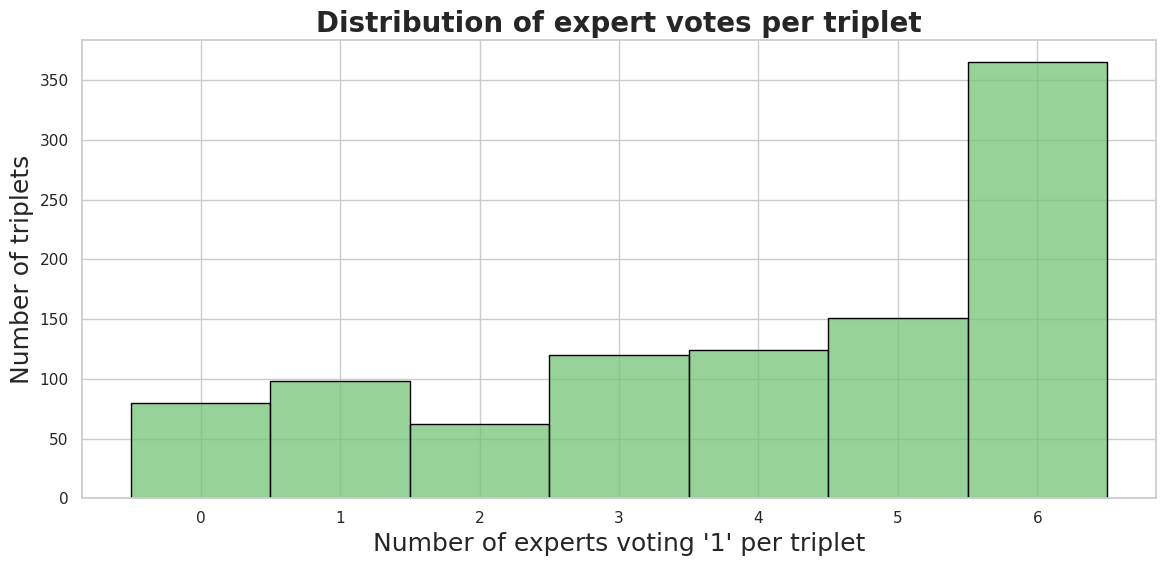

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Experts columns
experts = [f'Expert_{i}' for i in range(1, 7)]

# Count votes per triplet
vote_counts = new_df[experts].sum(axis=1)  # number of "1" votes per triplet

# Prepare plot style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 18})

plt.figure(figsize=(12, 6))
sns.histplot(vote_counts, bins=range(0, 8), discrete=True, color='#74C476', edgecolor='black')

plt.xlabel("Number of experts voting '1' per triplet", fontsize=18)
plt.ylabel("Number of triplets", fontsize=18)
plt.title("Distribution of expert votes per triplet", fontsize=20, weight='bold')
plt.xticks(range(0, 7))
plt.tight_layout()
#plt.savefig('./plots/experts_agreement.png', dpi=DPI, bbox_inches='tight')

plt.show()

In [103]:
# Fraction of 1s in Majority vote per Disaster Type + count
majority_fraction_by_disaster = (
    new_df
    .groupby('Disaster Type')
    .agg(
        Fraction_1=('Majority', 'mean'),
        N=('Majority', 'size')  # number of triplets per disaster type
    )
    .reset_index()
    .sort_values('Fraction_1', ascending=False)
)

majority_fraction_by_disaster

,Disaster Type,Fraction_1,N
12,Gas leak,1.000000,1
17,Miscellaneous accident (General),1.000000,1
13,Glacial lake outburst flood,1.000000,5
2,Collapse (Miscellaneous),0.818182,11
7,Explosion (Miscellaneous),0.812500,16
1,Collapse (Industrial),0.750000,4
21,Volcanic activity,0.750000,16
16,Mass movement (wet),0.743590,39
8,Extreme temperature,0.727273,11
23,Wildfire,0.675676,37


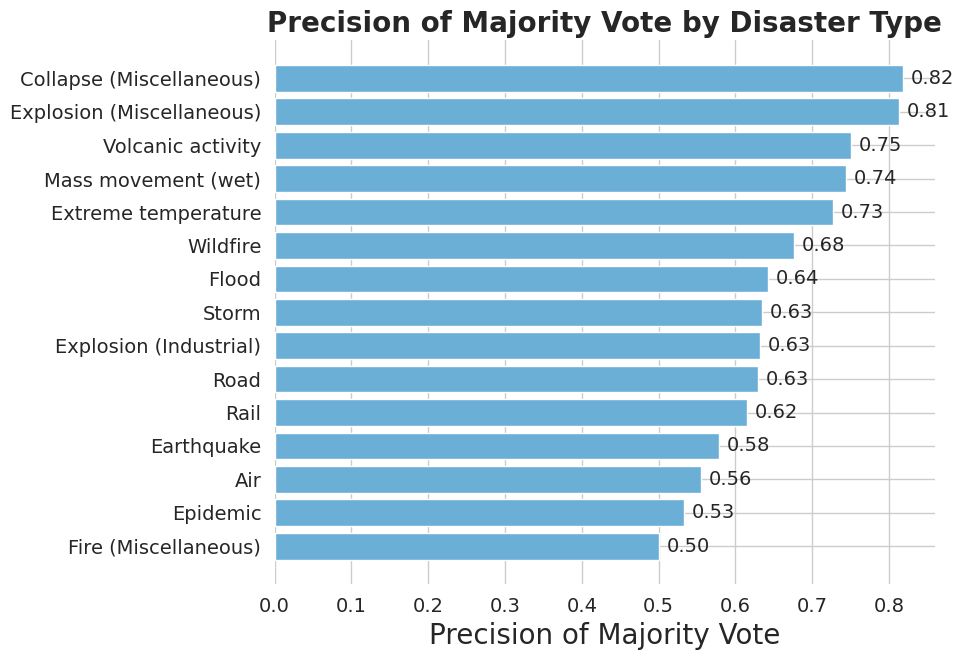

In [104]:

# --- Prepare data ---
majority_fraction_filtered = (
    majority_fraction_by_disaster
    .query("N > 10")
    .sort_values("Fraction_1", ascending=True)  # for horizontal bar plot
)

# --- Plot styling ---
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 20})
bar_color = '#6BAED6'  # pastel blue

# --- Plot ---
plt.figure(figsize=(10, 7))
ax = plt.barh(
    majority_fraction_filtered['Disaster Type'],
    majority_fraction_filtered['Fraction_1'],
    color=bar_color
)

# Labels
plt.xlabel('Precision of Majority Vote', fontsize=20)
plt.ylabel('')
plt.title('Precision of Majority Vote by Disaster Type', fontsize=20, weight='bold')

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate bars with fraction
for i, row in majority_fraction_filtered.iterrows():
    plt.text(
        row['Fraction_1'] + 0.01,  # slightly offset
        row['Disaster Type'],
        f"{row['Fraction_1']:.2f}",
        va='center',
        fontsize=14
    )

# Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

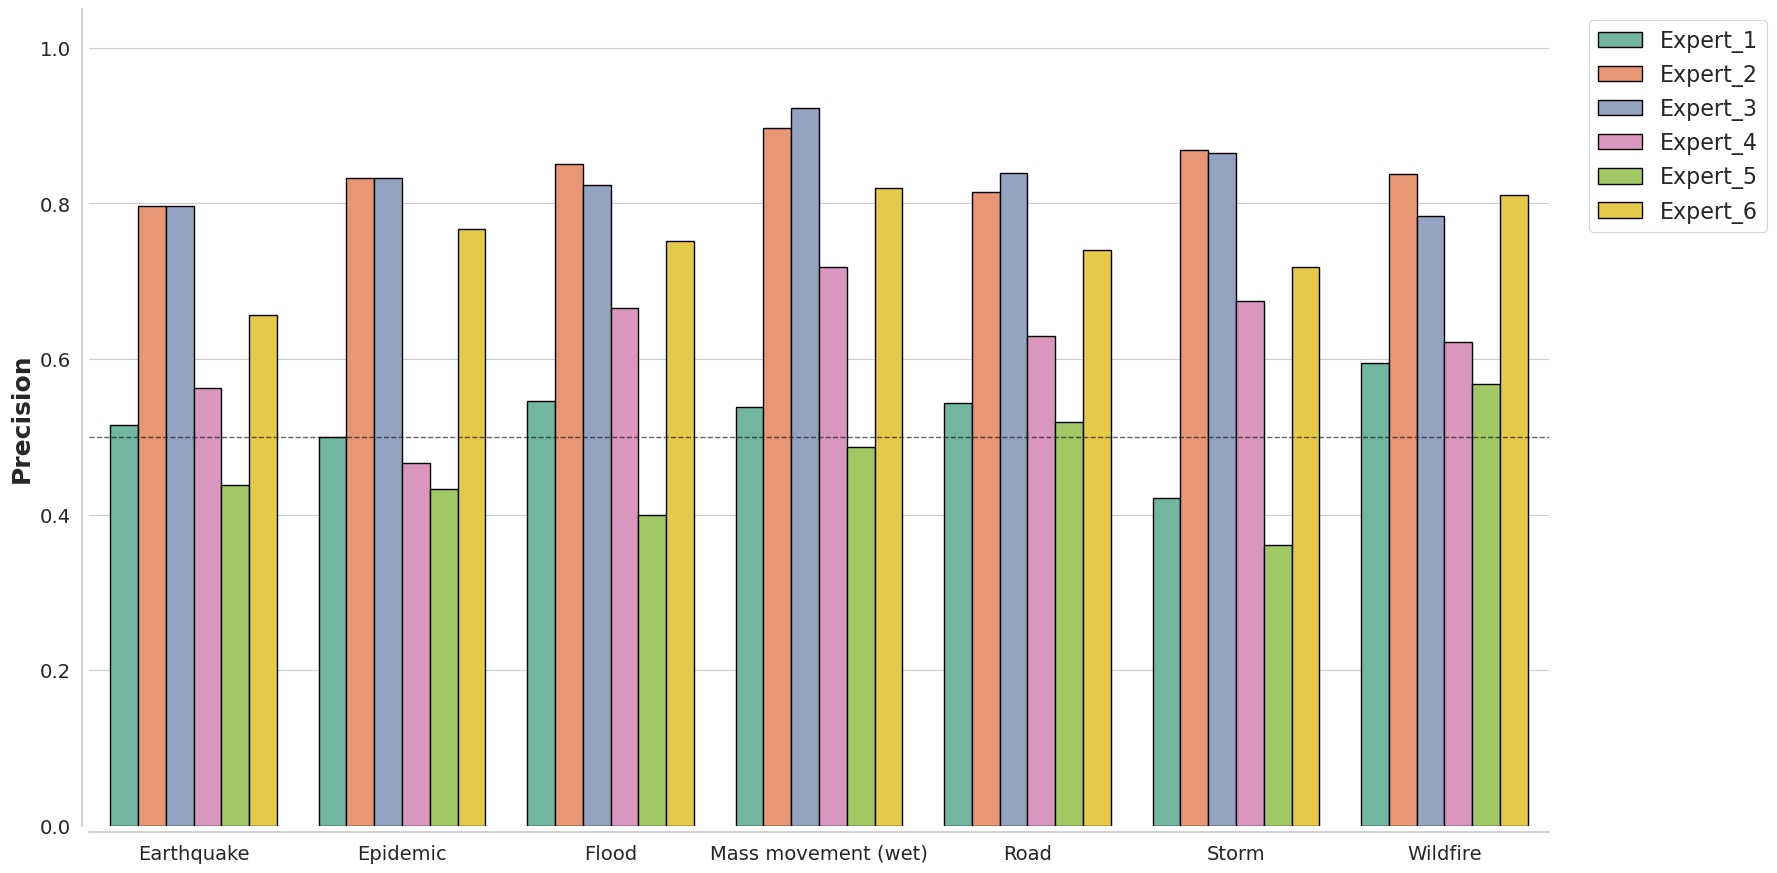

In [105]:

FONT_SIZE_TITLE = 20
FONT_SIZE_AXIS = 18
FONT_SIZE_TICK = 18
FONT_SIZE_LEGEND = 16
DPI = 300
BAR_PALETTE = 'Set2'  # pastel colors

# --- List of expert columns ---
experts = [f'Expert_{i}' for i in range(1, 7)]

# --- Compute fraction of 1s per expert per disaster type ---
fractions_by_disaster = (
    new_df
    .groupby('Disaster Type')
    .agg(N=('Majority', 'size'), **{exp: (exp, 'mean') for exp in experts})
    .reset_index()
)

# Filter for N > 10
fractions_filtered = fractions_by_disaster.query("N > 20")

# Melt for Seaborn
plot_data = pd.melt(
    fractions_filtered,
    id_vars=['Disaster Type'],
    value_vars=experts,
    var_name='Expert',
    value_name='Fraction_1'
)

# --- Figure init ---
fig, ax = plt.subplots(figsize=(18, 9))
sns.set_context("paper", font_scale=1.6)
sns.set_style("ticks")

# --- Barplot ---
bar_plot = sns.barplot(
    x='Disaster Type',
    y='Fraction_1',
    hue='Expert',
    data=plot_data,
    palette=BAR_PALETTE,
    edgecolor='black',
    linewidth=1.0,
    ax=ax
)

# Labels & ticks
ax.set_ylabel('Precision', fontsize=FONT_SIZE_AXIS, fontweight='bold')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.xticks(fontsize=22)  # also increase here

ax.set_ylim(0, 1.05)

# Legend
leg = ax.legend(
    title='',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=FONT_SIZE_LEGEND
)

# Reference line at 0.5
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

# Despine
sns.despine(offset=5)

# Adjust layout
fig.subplots_adjust(bottom=0.25, right=0.85)
plt.tight_layout()

# Save figure
#plt.savefig('./plots/triplet_fraction_experts.png', dpi=DPI, bbox_inches='tight')
plt.show()

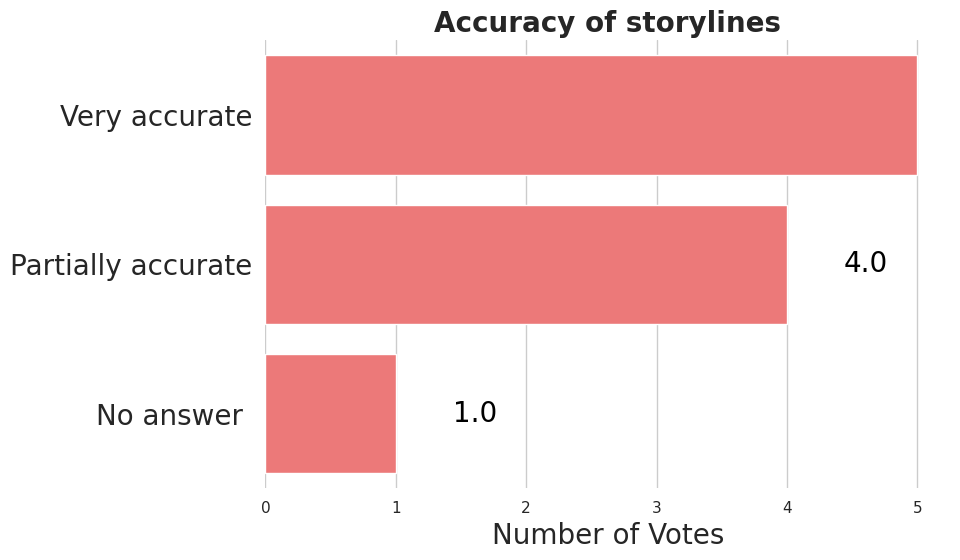

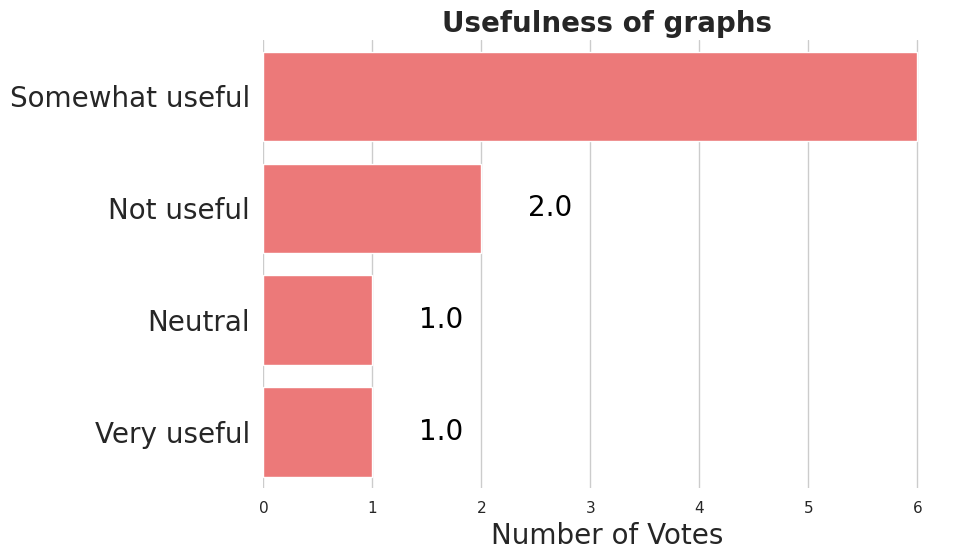

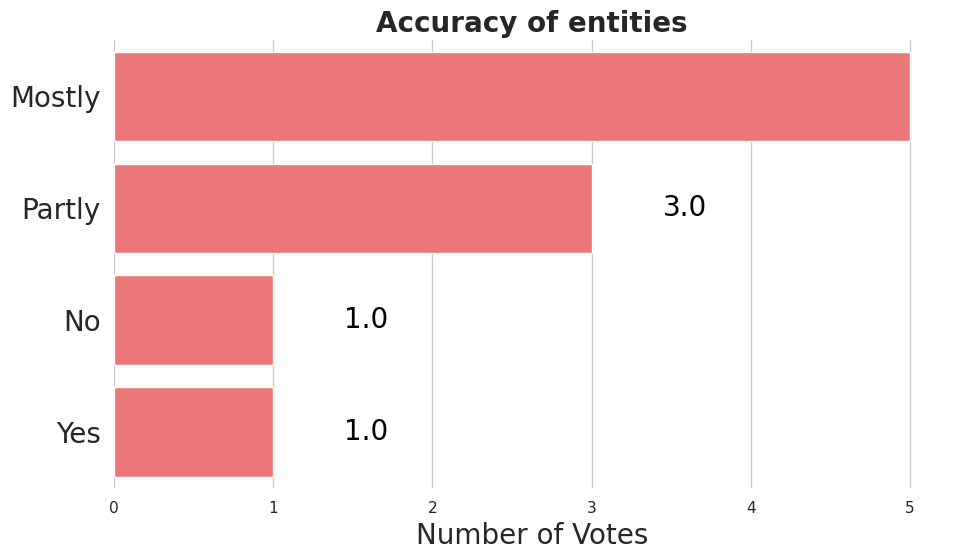

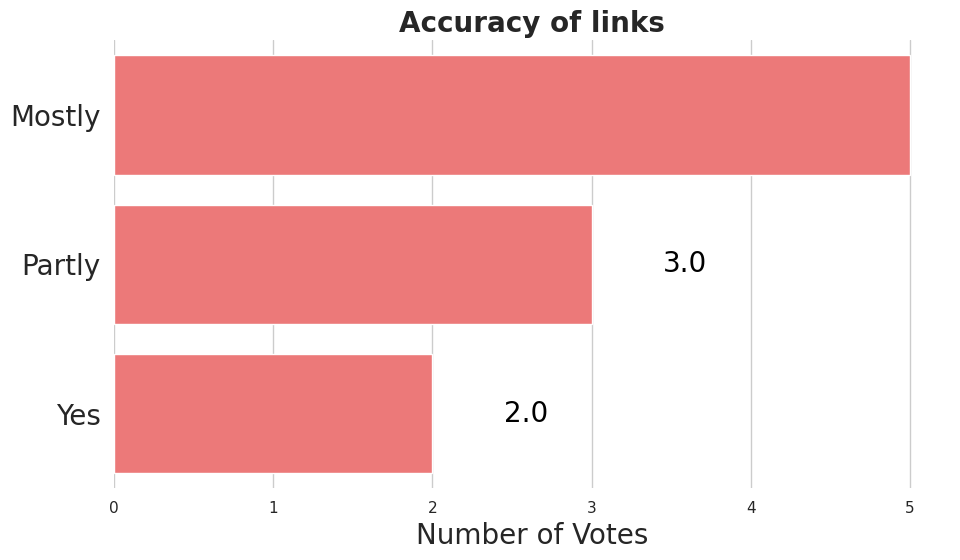

In [93]:

# Load the data
survey = pd.read_excel("./data/survey.xlsx")

# Set the style and context
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 20})

# Define a color for the bars
bar_color = '#FF6666'  # A professional, muted red

# Plot histograms for each column
columns = survey.columns
for column in columns:
    plt.figure(figsize=(10, 6))
    
    # Create the horizontal bar plot
    ax = sns.countplot(y=survey[column], color=bar_color, order=survey[column].value_counts().index)
    
    # Titles and labels
    plt.title(f'{column}', fontsize=20, weight='bold')
    plt.xlabel('Number of Votes', fontsize=20)
    plt.ylabel('')
    
    # Annotate bars with their counts
    for p in ax.patches:
        ax.annotate(f'{p.get_width()}', (p.get_width() + 0.5, p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', fontsize=20, color='black', xytext=(10, 0), 
                    textcoords='offset points')

    # Remove spines for a cleaner look
    sns.despine(left=True, bottom=True)
    ax.tick_params(axis='y', labelsize=20)
    
    # Adjust layout for tight presentation
    plt.tight_layout()
    #plt.savefig(f'{column}_evaluation.png', dpi=300, bbox_inches='tight', format='png')
    
    # Show plot
    plt.show()